# **This model would be for predicting the health of the traffic systemm we have build in Lanezy**

# Install Libraries

In [8]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# Loading CSV

In [9]:
df = pd.read_csv('data.csv')

In [10]:
df.head()

,voltage,packet_loss,response_time,sensor_health,system_health_percent
0,5.149014,0.013925,106.965725,0.966374,77.601337
1,4.958521,0.004725,105.666472,0.976329,85.762416
2,5.194307,0.009869,81.269603,0.886650,76.467290
3,5.456909,0.025521,111.591684,0.874938,55.096911
4,4.929754,0.079859,70.198346,0.922540,75.237361


# Comparing Quantities

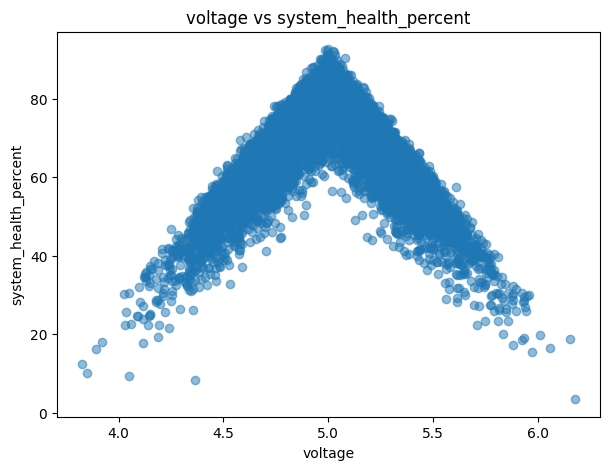

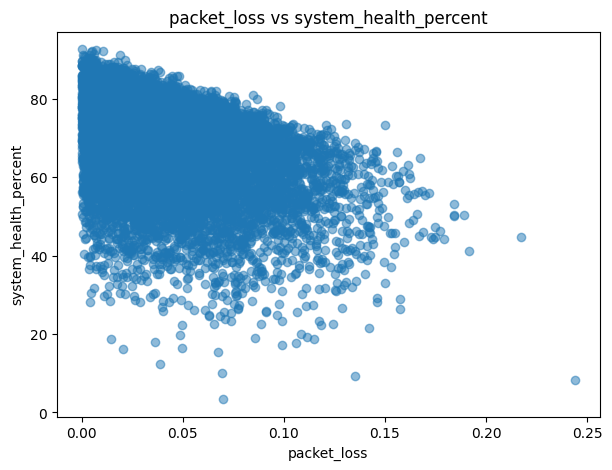

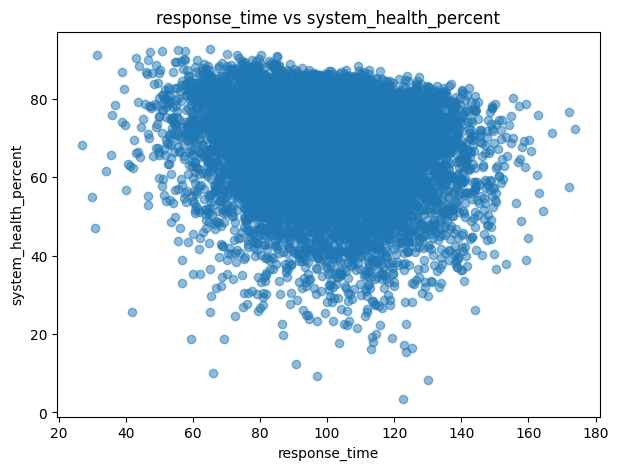

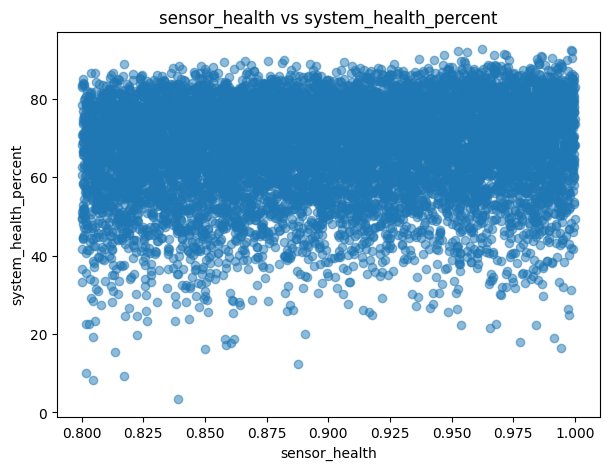

In [11]:
# Target column
target = "system_health_percent"

# Loop through each feature and plot against target
for col in df.columns:
    if col != target:
        plt.figure(figsize=(7,5))
        plt.scatter(df[col], df[target], alpha=0.5)
        plt.xlabel(col)
        plt.ylabel(target)
        plt.title(f"{col} vs {target}")
        plt.show()

We are Receiving good Graphs

# Some Basic Info

In [12]:
df.describe()

,voltage,packet_loss,response_time,sensor_health,system_health_percent
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.999359,0.043160,99.750745,0.899788,67.155351
std,0.301039,0.032705,19.828363,0.058071,12.196330
min,3.823280,0.000003,26.898270,0.800003,3.406241
25%,4.798223,0.017268,85.996962,0.849176,59.766294
50%,4.999222,0.036121,99.884635,0.899276,69.160187
75%,5.201324,0.062550,113.277949,0.950910,76.362864
max,6.177871,0.243954,173.832490,0.999994,92.641960


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   voltage                10000 non-null  float64
 1   packet_loss            10000 non-null  float64
 2   response_time          10000 non-null  float64
 3   sensor_health          10000 non-null  float64
 4   system_health_percent  10000 non-null  float64
dtypes: float64(5)
memory usage: 390.8 KB


In [14]:
df.isnull().sum()

,0
voltage,0
packet_loss,0
response_time,0
sensor_health,0
system_health_percent,0


No non null values

# Moving Forward with normalisation

In [15]:
X = df.drop("system_health_percent", axis=1)
y = df["system_health_percent"]

In [32]:
from sklearn.preprocessing import StandardScaler

# Scale features
scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X)

y_array = y.values.reshape(-1, 1)  # if y is a pandas Series

# Scale target
scaler_y = StandardScaler()
y_scaled = scaler_y.fit_transform(y_array)

# Splitting Dataset

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split first (use raw X and y)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Scale features
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)  # use same scaler

# Scale target
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1,1))
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1,1))  # optional, if you want to evaluate scaled

# Now train the model
from sklearn.ensemble import GradientBoostingRegressor
model = GradientBoostingRegressor(random_state=42)
model.fit(X_train_scaled, y_train_scaled.ravel())


GradientBoostingRegressor(random_state=42)

In [34]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# Predict on training set
y_train_pred_scaled = model.predict(X_train_scaled)
y_train_pred = scaler_y.inverse_transform(y_train_pred_scaled.reshape(-1,1))

# Predict on test set
y_test_pred_scaled = model.predict(X_test_scaled)
y_test_pred = scaler_y.inverse_transform(y_test_pred_scaled.reshape(-1,1))

# Evaluate train set
train_r2 = r2_score(y_train, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))

# Evaluate test set
test_r2 = r2_score(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print(f"Train R2 Score: {train_r2:.4f}")
print(f"Train RMSE: {train_rmse:.4f}")
print(f"Test R2 Score: {test_r2:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")


Train R2 Score: 0.9964
Train RMSE: 0.7366
Test R2 Score: 0.9937
Test RMSE: 0.9585


# Trying out different ML Models

In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "Support Vector Regressor": SVR(),
    "K-Nearest Neighbors": KNeighborsRegressor()
}

In [19]:
from sklearn.metrics import mean_squared_error, r2_score


results = {}

# Training & Evaluation
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    results[name] = {"MSE": mse, "R2": r2}

# Display results
results_df = pd.DataFrame(results).T
print(results_df)

                                 MSE        R2
Linear Regression         118.970509  0.183498
Random Forest               1.251388  0.991412
Gradient Boosting           0.915537  0.993717
Support Vector Regressor    5.176682  0.964472
K-Nearest Neighbors         5.134934  0.964759


Best is Gradient Boosting

# Hyper parameter Tuning

In [30]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(random_state=42)

param_grid = {
    'n_estimators': [100, 200],           # instead of 3 values
    'learning_rate': [0.05, 0.1],         # instead of 3
    'max_depth': [3, 5],                  # instead of 3
    'min_samples_split': [2, 5],          # instead of 3
    'min_samples_leaf': [1, 2],           # instead of 3
    'subsample': [0.8, 1.0]               # same
}

grid_search = GridSearchCV(
    estimator=gbr,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best R2 Score:", grid_search.best_score_)


Fitting 5 folds for each of 64 candidates, totalling 320 fits
Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200, 'subsample': 0.8}
Best R2 Score: 0.9971267007237126


# Training on best params

In [22]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# Adjusted parameters to reduce overfitting
adjusted_params = {
    'learning_rate': 0.05,
    'max_depth': 4,
    'min_samples_leaf': 3,
    'min_samples_split': 2,
    'n_estimators': 300,
    'subsample': 0.8,
    'random_state': 42
}

# Train the model
model = GradientBoostingRegressor(**adjusted_params)
model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)

# Evaluate
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Test R2 Score: {r2:.4f}")
print(f"Test RMSE: {rmse:.4f}")

# Train score to check overfitting
train_r2 = r2_score(y_train, model.predict(X_train))
print(f"Train R2 Score: {train_r2:.4f}")


Test R2 Score: 0.9972
Test RMSE: 0.6333
Train R2 Score: 0.9990


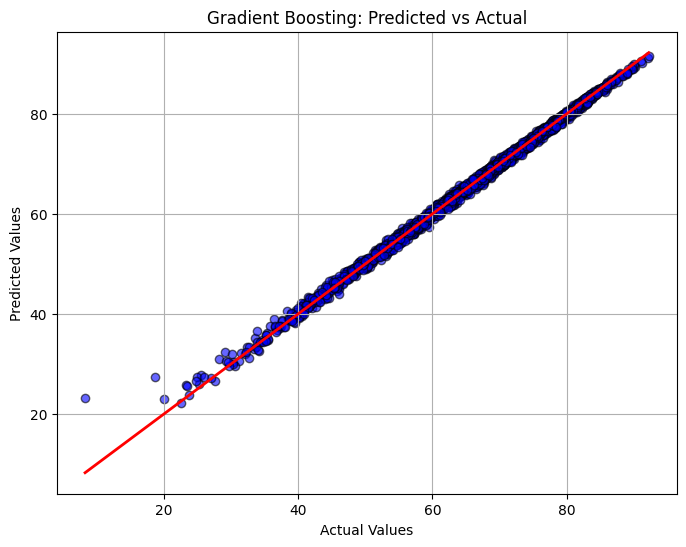

In [23]:
import matplotlib.pyplot as plt

# Plot predicted vs actual
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='blue', edgecolor='k')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linewidth=2)  # perfect fit line
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Gradient Boosting: Predicted vs Actual")
plt.grid(True)
plt.show()


In [35]:
import numpy as np

# Example: 5 new samples (make sure they are realistic within training feature ranges)
new_samples = np.array([
    [5.45, 0.002, 75.0, 0.98],
    [5.40, 0.001, 80.0, 0.97],
    [5.35, 0.003, 78.0, 0.99],
    [5.50, 0.000, 72.0, 0.995],
    [5.48, 0.001, 76.0, 0.98]
])

# Scale features using the same scaler as training
new_samples_scaled = scaler_X.transform(new_samples)

# Predict in scaled target space
y_pred_scaled = model.predict(new_samples_scaled)

# Inverse-transform to get actual system health percentages
y_pred_actual = scaler_y.inverse_transform(y_pred_scaled.reshape(-1,1))

# Display results
for i, pred in enumerate(y_pred_actual, start=1):
    print(f"Sample {i} Predicted System Health Percent: {pred[0]:.2f}")


Sample 1 Predicted System Health Percent: 64.96
Sample 2 Predicted System Health Percent: 66.53
Sample 3 Predicted System Health Percent: 69.62
Sample 4 Predicted System Health Percent: 62.32
Sample 5 Predicted System Health Percent: 62.17


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [36]:
import numpy as np

high_health_samples = np.array([
    [5.50, 0.0005, 75.0, 0.995],
    [5.48, 0.0010, 72.0, 0.990],
    [5.52, 0.0002, 78.0, 0.998],
    [5.49, 0.0008, 74.0, 0.992],
    [5.51, 0.0003, 76.0, 0.997]
])

# Scale features
high_health_scaled = scaler_X.transform(high_health_samples)

# Predict
y_pred_scaled = model.predict(high_health_scaled)

# Inverse transform to get actual system health %
y_pred_actual = scaler_y.inverse_transform(y_pred_scaled.reshape(-1,1))

# Display
for i, pred in enumerate(y_pred_actual, start=1):
    print(f"Sample {i} Predicted System Health Percent: {pred[0]:.2f}")


Sample 1 Predicted System Health Percent: 62.21
Sample 2 Predicted System Health Percent: 62.79
Sample 3 Predicted System Health Percent: 59.98
Sample 4 Predicted System Health Percent: 62.21
Sample 5 Predicted System Health Percent: 60.09


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [29]:
print(X_train.min())
print(X_train.max())


-3.906933007492303
5.319226762205089


In [37]:
import joblib

# Save the trained Gradient Boosting model
joblib.dump(model, 'gradient_boosting_model.pkl')

# Save the feature scaler
joblib.dump(scaler_X, 'scaler_X.pkl')

# Optionally, save the target scaler as well
joblib.dump(scaler_y, 'scaler_y.pkl')

print("Model and scalers saved successfully!")


Model and scalers saved successfully!
